# Imports:

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.cm as cm
import numpy as np
import torch
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sentence_transformers import SentenceTransformer
from sklearn.preprocessing import StandardScaler

c:\Users\thoma\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Dataset:

For this project we use the Smell Pittsburgh dataset:

In [2]:
df_irregular = pd.read_csv("data/smell.csv")

# Loading external models:

This model is trained on data that includes stopwords and capital letters. So there is minimal extra preprocessing required to make embeddings from the textual data from the dataset.

In [3]:
model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 3399.65it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In order to visualize the data from both the TF-IDF and embeddings, we will use <i>Priciple Component Analasys</i> (PCA) to reduce the dimensions of the textual data.

# Text preprocessing

We first try to make an TF-IDF and plot these using PCA.

In [5]:
df_text = df_irregular.copy()

In [6]:
df_text["date & time"] = pd.to_datetime(df_text["date & time"], utc=True)
df_text = df_text.set_index("date & time").sort_index()

We combine the three different column to create a richer context for better drift detection.

In [7]:
df_text["combined"] = df_text["smell description"].fillna("") + " " + df_text["symptoms"].fillna("") + " " + df_text["additional comments"].fillna("")

Stopwords are removed as part of the preprocessing

In [8]:
tfidf_comments = TfidfVectorizer(stop_words="english", max_features=1000)

combined= tfidf_comments.fit_transform(df_text["combined"].fillna(""))

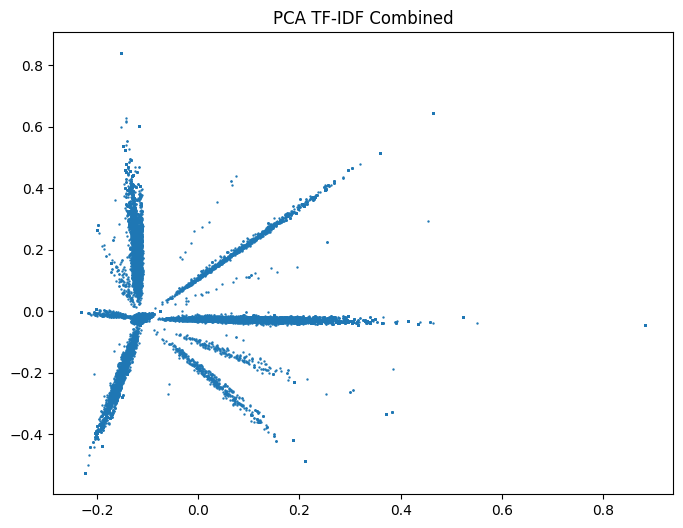

In [9]:
pca = PCA(n_components=2).fit_transform(combined.toarray())

plt.figure(figsize=(8,6))
plt.title("PCA TF-IDF Combined")
plt.scatter(pca[:, 0], pca[:, 1], s=0.5)

In the plot above we can see a lot of spikes in the dataset. This is suboptimal for drift detection, since we see very little change in directions. Thus a TF-IDF isn't suited for our problem. A better strategy is to use embeddings.

In [10]:
embeddings = model.encode(df_text["combined"].tolist())

In [11]:
pca = PCA(n_components=2)
embeddings_2d  = pca.fit_transform(embeddings)

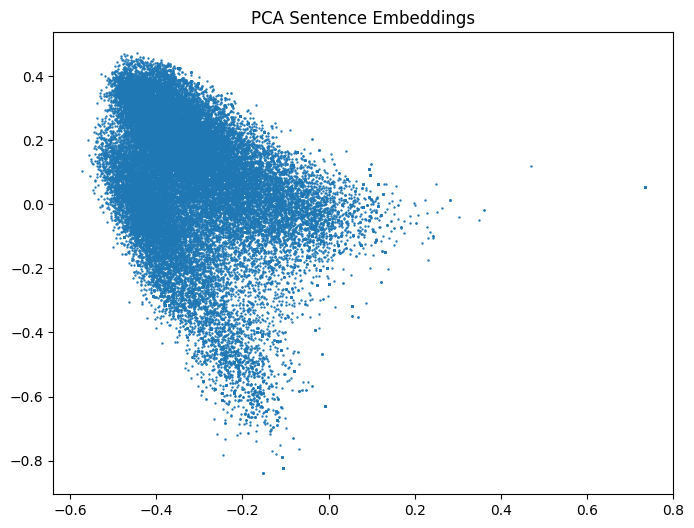

In [12]:
plt.figure(figsize=(8,6))
plt.title("PCA Sentence Embeddings")
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], s=0.5)

# Regular Dataset

Creating the regular baseline dataset from the Smell Pittsburgh dataset.

Printing the head of the dataset to compare to the final result.

In [13]:
print(df_irregular.head())

   epoch time                 date & time  smell value  skewed latitude  \
0  1577836610  01/01/2020 00:56:50 +01:00            3        40.557110   
1  1577850486  01/01/2020 04:48:06 +01:00            3        40.423138   
2  1577852394  01/01/2020 05:19:54 +01:00            3        40.381115   
3  1577857682  01/01/2020 06:48:02 +01:00            3        40.307728   
4  1577883411  01/01/2020 13:56:51 +01:00            3        40.307781   

   skewed longitude  zipcode                                smell description  \
0        -80.059578    15237  Sulfur. Hydrogen Sulfide.  Clairton Coke Works.   
1        -79.920387    15217                                       Industrial   
2        -79.860985    15110                                      Industrial    
3        -79.860908    15037                                us steel clairton   
4        -79.860908    15037                               u s steel clairton   

                         symptoms  \
0  Sore throat and lungs.

Initiliaze the regular sampled dataset as a copy of the irregular dataset.

In [14]:
df_regular = df_irregular.copy()

Make the 'date & time' column the index of the new dataset. This is done in order to resample the data in the next step. The column is also made into a <i>datetime</i>, to ensure correct interpertation by pandas.

In [15]:
df_regular["date & time"] = pd.to_datetime(df_regular["date & time"], utc=True)
df_regular = df_regular.set_index("date & time").sort_index()

In [16]:
df_temp = df_irregular.copy()

## Adding the text data to the regular dataset

We first combine the data together as done with the TF-IDF, afterwards we resample the data to hourly. If there are more reports with text, all the text gets added into one cell.

In [17]:
df_temp["date & time"] = pd.to_datetime(df_temp["date & time"], utc=True)
df_temp = df_temp.set_index("date & time").sort_index()

df_temp["combined"] = (df_temp["smell description"].fillna("") + " " + df_temp["symptoms"].fillna("") + " " + df_temp["additional comments"].fillna(""))

Creating the embeddings of the text:

In [18]:
pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(embeddings)

df_temp["text_emb_1"] = embeddings_2d[:, 0]
df_temp["text_emb_2"] = embeddings_2d[:, 1]

Resampling of the dataset:

In [19]:
df_regular = df_temp.resample("1h").agg(
    count=("smell value", "size"),
    mean_smell=("smell value", "mean"),
    latitude_mean=("skewed latitude", "mean"),
    latitude_std=("skewed latitude", "std"),
    longitude_mean=("skewed longitude", "mean"),
    longitude_std=("skewed longitude", "std"),
    combined=("combined", " ".join), 
    text_emb_1_mean=("text_emb_1", "mean"),
    text_emb_1_std=("text_emb_1", "std"),
    text_emb_2_mean=("text_emb_2", "mean"),
    text_emb_2_std=("text_emb_2", "std"),
    )

In [20]:
df_regular = df_regular.fillna(0)

In [21]:
print(df_regular.head)

<bound method NDFrame.head of                            count  mean_smell  latitude_mean  latitude_std  \
date & time                                                                 
2019-12-31 23:00:00+00:00      1         3.0      40.557110           0.0   
2020-01-01 00:00:00+00:00      0         0.0       0.000000           0.0   
2020-01-01 01:00:00+00:00      0         0.0       0.000000           0.0   
2020-01-01 02:00:00+00:00      0         0.0       0.000000           0.0   
2020-01-01 03:00:00+00:00      1         3.0      40.423138           0.0   
...                          ...         ...            ...           ...   
2025-12-31 15:00:00+00:00      0         0.0       0.000000           0.0   
2025-12-31 16:00:00+00:00      0         0.0       0.000000           0.0   
2025-12-31 17:00:00+00:00      0         0.0       0.000000           0.0   
2025-12-31 18:00:00+00:00      0         0.0       0.000000           0.0   
2025-12-31 19:00:00+00:00      1         5.0  

Saving the dataset as an .csv

In [22]:
df_regular.to_csv("data/smell_regular.csv")

# Irregular dataset

In [23]:
df_irregular["date & time"] = pd.to_datetime(df_irregular["date & time"], utc=True)
df_irregular = df_irregular.set_index("date & time").sort_index()

In [24]:
df_irregular["combined"] = (df_irregular["smell description"].fillna("") + " " + df_irregular["symptoms"].fillna("") + " " + df_irregular["additional comments"].fillna(""))

In [25]:
pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(embeddings)

df_irregular["text_emb_1"] = embeddings_2d[:, 0]
df_irregular["text_emb_2"] = embeddings_2d[:, 1]

In [26]:
df_irregular = df_irregular.fillna(0)

In [27]:
print(df_irregular.head)

<bound method NDFrame.head of                            epoch time  smell value  skewed latitude  \
date & time                                                           
2019-12-31 23:56:50+00:00  1577836610            3        40.557110   
2020-01-01 03:48:06+00:00  1577850486            3        40.423138   
2020-01-01 04:19:54+00:00  1577852394            3        40.381115   
2020-01-01 05:48:02+00:00  1577857682            3        40.307728   
2020-01-01 12:56:51+00:00  1577883411            3        40.307781   
...                               ...          ...              ...   
2025-12-29 18:44:04+00:00  1767033844            3        40.501625   
2025-12-29 19:03:30+00:00  1767035010            2        40.480525   
2025-12-31 09:47:55+00:00  1767174475            1        40.484813   
2025-12-31 14:36:50+00:00  1767191810            1        40.424848   
2025-12-31 19:49:30+00:00  1767210570            5        40.396370   

                           skewed longitude  z

In [28]:
df_irregular.to_csv("data/smell_irregular.csv")

## Visualizing the data

Different plots of the data, based on location and comments a day:

In [29]:
print(df_irregular.columns)

Index(['epoch time', 'smell value', 'skewed latitude', 'skewed longitude',
       'zipcode', 'smell description', 'symptoms', 'additional comments',
       'combined', 'text_emb_1', 'text_emb_2'],
      dtype='object')


In [ ]:
df_irregular["year"] = pd.to_datetime(df_irregular["date & time"], errors="coerce", utc=True)
df_irregular["year"] = df_irregular["year"].dt.year

plt.figure(figsize=(8,6))

for i in df_irregular["year"].dropna().unique():
    subset = df_irregular[df_irregular["year"] == i]
    
    plt.scatter(subset["skewed longitude"], subset["skewed latitude"], label=str(i), s=0.5)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Report locations")
plt.legend(title="Year")

plt.show()

'df_irregular["year"] = pd.to_datetime(df_irregular["date & time"], errors="coerce", utc=True)\ndf_irregular["year"] = df_irregular["year"].dt.year\n\nplt.figure(figsize=(8,6))\n\nfor i in df_irregular["year"].dropna().unique():\n    subset = df_irregular[df_irregular["year"] == i]\n\n    plt.scatter(subset["skewed longitude"], subset["skewed latitude"], label=str(i), s=0.5)\n\nplt.xlabel("Longitude")\nplt.ylabel("Latitude")\nplt.title("Report locations")\nplt.legend(title="Year")\n\nplt.show()'